<a href="https://colab.research.google.com/github/PMSense/AI-Security-/blob/main/Poisoning_Attack_Pipeline_vFinal3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#**Author:** Slam Laqtib


#**Project Execution Plan: Adversarial Attacks on AI-Based Network IDS**

# **1. Problem Statement**

Modern Network Intrusion Detection Systems (NIDS) increasingly **rely on Machine Learning (ML) to identify malicious traffic**. While these models are powerful, they rely entirely on the quality of their training data. **This creates a critical vulnerability**: **Data Poisoning**.

If an attacker can infiltrate the data supply chain (e.g., through crowdsourcing, insider threats, or feedback loop abuse) and mislabel malicious traffic as "Safe," they can create a permanent blindspot in the security system.

# 2. **Project Objective**
This project aims to experimentally demonstrate the fragility of ML-based security systems. We will:

1. **Build & Test** a standard Random Forest NIDS model.

2. **Attack**
- Zero-Day Attack — test the model against Zero-day attack
- Data Poisoning Attack — the model using a "Label Flipping" **poisoning** technique to blind it to Denial of Service (DoS) attacks.

3. **Defend** the system by implementing a trusted data retraining pipeline.

# **3. Dataset & Methodology**

We utilize the Canadian Institute for Cybersecurity Intrusion Detection System 2017 **[CIC-IDS-2017](https://www.kaggle.com/datasets/bcccdatasets/intrusion-detection-datasets-bccc-cic-ids-2017)** dataset, a comprehensive benchmark for network security.

- **The Baseline Data**: We train our initial model on "Benign" traffic and common attacks (e.g., PortScans, Web Attacks).

- **The "Zero-Day" Threat**: We sequester specific DoS and Botnet attacks (e.g., DoS_Hulk, Botnet_ARES) to simulate a new, unknown threat vector.

# **4. Execution Phases**

**Phase I: Baseline Development & Vulnerability Check**

We **build, train & test** a Random Forest classifier on standard network traffic. We then test this model against our sequestered "**Zero-Day**" DoS attacks.

- **Hypothesis:** The model will struggle to detect these new attacks (Low Recall) because it has never seen their specific signatures, representing a "Knowledge Gap."

**Phase II: The Adversarial Attack (Stealth Poisoning)**

We simulate a supply-chain attack where a threat actor injects the DoS attack data into the training set but **flips the labels** to "Benign." We perform a "Stealth Campaign," incrementally increasing the percentage of poisoned data (1%, 5%, 10%) to find the model's breaking point.

- **Hypothesis:** Even a small amount of poisoned data (1-5%) will teach the model that high-volume traffic is safe, dropping the detection rate to 0.00% and creating a total blindspot.

**Phase III: Defense & Remediation**

We implement a defense strategy based on **Data Provenance**. We sanitize the labels of the DoS attack data (correcting them from "Benign" to "Attack") and retrain the model.

- **Hypothesis:** By feeding the model trusted, correctly labeled ground truth, we will repair the decision boundary and restore the detection rate to near 100%.

# **5. Evaluation Metrics**
We focus primarily on Recall (Sensitivity) for the Attack class. **In cybersecurity, Recall is the most critical metric**: it measures what percentage of actual attacks were caught.

- **Low Recall** = Attacks are entering the network undetected.

- **High Recall** = The system is secure.


---



# **Milestone 1: Environment Setup & Library Import**

**Objective**

To establish the computational environment and import necessary tools for data manipulation and machine learning.

**Key Concepts**

- Pandas (pd): The industry-standard library for data manipulation. It allows us to load CSVs into "DataFrames" (programmable spreadsheets).

- Numpy (np): Used for high-performance numerical calculations.

- Scikit-Learn (sklearn): The machine learning framework we use to build, train, and evaluate our models.

**Implementation Details**

We import RandomForestClassifier (our model choice) and StandardScaler (for data normalization). We also configure the environment to suppress non-critical warnings to ensure clean output reporting.

In [ ]:
# [Milestone 1] Initial Import of libraries
# ------------------------------------------------------------------------------
# Documentation:
# This cell sets up the environment. We import standard data science libraries
# (Pandas, Numpy) and the Scikit-Learn framework for Machine Learning.
# We also suppress warnings to keep our report clean.
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import glob
import os
import warnings

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Suppress common warnings for cleaner output
warnings.filterwarnings(action='ignore', category=UserWarning)

print("Libraries imported successfully.")

Libraries imported successfully.


# **Milestone 2: Data Preparation & Preprocessing**

**Objective**

To transform raw, messy network logs into a clean, numerical format that a machine learning model can understand.

**Key Concepts**

- **Feature Selection**: We remove columns like Source IP, Destination IP, and Timestamp.

  - Why? Using IP addresses leads to "overfitting." The model might learn that "IP 192.168.1.5 is bad," which is useless because attackers change IPs constantly. We want the model to learn behavior (packet size, rate), not identity.

- **Class Imbalance (problem)**: In network traffic, 99% of data is "Benign" (normal) and only 1% is malicious. If we train on this raw data, the model becomes lazy and just predicts "Benign" for everything to get 99% accuracy.

- **Downsampling (fix)**: To fix class imbalance and prevent memory crashes (RAM exhaustion), we randomly sample a smaller portion of the "Benign" traffic while keeping the malicious traffic. **This creates a balanced dataset for efficient training**.

**Implementation Details**

1.   **Loading:** We load 18 CSV files from the CIC-IDS-2017 dataset.
2.   **Simulation Setup:** We explicitly extract specific DoS attacks (e.g., DoS_Hulk, DDoS_LOIT) into a separate dataframe (data_dos_attacks) and remove them from the main training set. This allows us to treat them as "Zero-Day" or "New" attacks later.
3.   **Encoding:** We convert text labels (Benign, DoS_Hulk) into binary numbers (0 for Benign, 1 for Attack).

In [ ]:
# [Milestone 2] Data Preparation (Corrected Logic)
# ------------------------------------------------------------------------------
# Documentation:
# 1. Connects to Google Drive.
# 2. Loads raw CSVs.
# 3. Encodes labels to 0/1 BEFORE converting data to numbers.
# ------------------------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Local environment detected.")

# --- Configuration ---
DRIVE_ROOT = '/content/drive/My Drive/'
DATA_PATH = os.path.join(DRIVE_ROOT, 'ML Project/Data Sets/BCCC-CIC-IDS-2017')
BENIGN_LABEL = 'Benign'
TARGET_ATTACK_LABELS = [
    'Botnet_ARES', 'DDoS_LOIT', 'DoS_GoldenEye',
    'DoS_Hulk', 'DoS_Slowhttptest', 'DoS_Slowloris'
]

# --- Helper Function ---
def load_and_process_data(path):
    print(f"Loading data from: {path}")
    csv_files = glob.glob(os.path.join(path, "*.csv"))
    if not csv_files:
        print("No files found. Check path.")
        return pd.DataFrame()

    df_list = []
    for f in csv_files:
        try:
            df = pd.read_csv(f, encoding='latin1', low_memory=False)
            df_list.append(df)
        except: pass

    data = pd.concat(df_list, ignore_index=True)

    # Clean Column Names
    data.columns = data.columns.str.strip()
    data.rename(columns={'label': 'Label', 'LABEL': 'Label'}, inplace=True)

    # Clean Label Values
    data['Label'] = data['Label'].str.strip()

    # Remove Non-Numeric Features
    cols_drop = ['Timestamp', 'Flow ID', 'Source IP', 'Destination IP', 'Source Port', 'Destination Port', 'Protocol']
    data.drop(columns=[c for c in cols_drop if c in data.columns], inplace=True, errors='ignore')

    # Handle NaNs/Infs
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.fillna(0, inplace=True)

    return data

# --- Execution ---
full_data = load_and_process_data(DATA_PATH)

if not full_data.empty:
    print("\nUnique Labels Found:", full_data['Label'].unique())

    # 1. Extract Target Attacks
    data_dos_attacks = full_data[full_data['Label'].isin(TARGET_ATTACK_LABELS)].copy()

    # 2. Create Baseline Data
    data_baseline = full_data.drop(data_dos_attacks.index).copy()

    # 3. Downsample
    benign_df = data_baseline[data_baseline['Label'] == BENIGN_LABEL]
    others_df = data_baseline[data_baseline['Label'] != BENIGN_LABEL]

    if len(benign_df) == 0:
        print("CRITICAL ERROR: No Benign Data Found!")
    else:
        benign_sampled = benign_df.sample(frac=0.1, random_state=42)
        others_sampled = others_df.sample(frac=0.2, random_state=42)

        # Combine sampled data
        data_train_subset = pd.concat([benign_sampled, others_sampled])

        # --- THE CRITICAL FIX IS HERE ---
        # 1. Encode Labels FIRST while they are still text
        y_train_binary = data_train_subset['Label'].apply(lambda x: 0 if str(x).strip() == BENIGN_LABEL else 1)

        # 2. Drop label column
        X_train_final = data_train_subset.drop(columns=['Label'])

        # 3. NOW convert features to numeric (safe to do now)
        X_train_final = X_train_final.apply(pd.to_numeric, errors='coerce').fillna(0)
        # --------------------------------

        # Process Target Attacks
        X_target = data_dos_attacks.drop(columns=['Label'])
        X_target = X_target.apply(pd.to_numeric, errors='coerce').fillna(0)
        y_target = pd.Series(1, index=X_target.index)

        print("-" * 30)
        print(f"Baseline Train Size: {len(X_train_final)}")
        print(f"  - Benign Labels (0): {len(y_train_binary[y_train_binary==0])}")
        print(f"  - Attack Labels (1): {len(y_train_binary[y_train_binary==1])}")
        print(f"Target Attack Size: {len(X_target)}")
        print("-" * 30)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data from: /content/drive/My Drive/ML Project/Data Sets/BCCC-CIC-IDS-2017

Unique Labels Found: ['Botnet_ARES' 'DDoS_LOIT' 'DoS_GoldenEye' 'DoS_Hulk' 'DoS_Slowhttptest'
 'DoS_Slowloris' 'FTP-Patator' 'Heartbleed' 'Benign' 'SSH-Patator'
 'Port_Scan' 'Web_Brute_Force' 'Web_SQL_Injection' 'Web_XSS']
------------------------------
Baseline Train Size: 214810
  - Benign Labels (0): 178624
  - Attack Labels (1): 36186
Target Attack Size: 470882
------------------------------



# **Milestone 3: Developing the Base Model**

**Objective**

To train a "clean" baseline model that represents the system's performance before any attack occurs.

**Key Concepts**

- **Random Forest Classifier**: An "Ensemble" learning method. Instead of relying on one decision tree, it intially **builds hundreds of trees and "votes" on the outcome**. It is highly robust and resistant to noise.

- **Standard Scaling**: ML models struggle when features have vastly different ranges (e.g., Packet Duration is 0-5 seconds, but Bytes Transferred is 0-1,000,000). Scaling forces all features to have a Mean of 0 and a Standard Deviation of 1, putting them on a level playing field.

- **Train/Test Split**: We hide 30% of our data during training to use as a "Final Exam." This ensures the model isn't just memorizing answers.

- **The "Zero-Day" Threat**: We sequester specific DoS and Botnet attacks (e.g., DoS_Hulk, Botnet_ARES) to simulate a new, unknown threat vector.

**Implementation Details**

We train the Random Forest on the clean X_train data. We then evaluate it on the X_test data to establish a baseline accuracy. Finally, we test it against our reserved DoS attacks to confirm that—while it detects known attacks well—it may struggle with these specific new patterns initially.

In [ ]:
# [Milestone 3] Develop Initial Base Model
# ------------------------------------------------------------------------------
# Documentation:
# 1. Train/Test Split: We hold back 30% of the baseline data to test accuracy.
# 2. Scaling: Standardize features (Mean=0, Std=1) to ensure model stability.
# 3. Training: Train a Random Forest Classifier on the known/clean data.
# 4. Evaluation: Test against known traffic AND the hidden Zero-Day attacks.
# ------------------------------------------------------------------------------

# Check if Milestone 2 ran successfully
if 'X_train_final' not in locals():
    print("CRITICAL ERROR: Variables from Milestone 2 not found.")
    print("Please run Milestone 2 before running this cell.")
else:
    print("--- Developing Base Model ---")

    # 1. Split Baseline Data (70% Train, 30% Test)
    # We stratify to ensure we keep the same ratio of Benign/Attacks in both sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_train_final, y_train_binary, test_size=0.3, random_state=42, stratify=y_train_binary
    )

    print(f"Training Data Shape: {X_train.shape}")
    print(f"Testing Data Shape: {X_test.shape}")

    # 2. Scale Data
    # Crucial: We fit the scaler ONLY on the training data, then apply it to others.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # We also need to scale our "Zero Day" target attacks using the SAME scaler
    X_target_scaled = scaler.transform(X_target)

    # 3. Train Model
    print("\nTraining Random Forest Model... (This may take a minute)")
    # n_jobs=-1 uses all CPU cores for faster training
    base_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
    base_model.fit(X_train_scaled, y_train)
    print("Training Complete.")

    # 4. Evaluation (Self-Check on Known Data)
    print("\n" + "="*60)
    print("REPORT 1: Base Model Performance on KNOWN Traffic")
    print("(How well does it handle Benign vs. PortScan/WebAttacks?)")
    print("="*60)
    y_pred = base_model.predict(X_test_scaled)

    # We use labels=[0, 1] to ensure both classes show up even if predictions are skewed
    print(classification_report(y_test, y_pred, labels=[0, 1], target_names=['Benign', 'Attack'], zero_division=0))

    # 5. Vulnerability Check (Against NEW DoS Attacks)
    print("\n" + "="*60)
    print("REPORT 2: Zero-Day Vulnerability Check")
    print("(How well does it handle the HIDDEN DoS attacks?)")
    print("="*60)

    y_pred_dos = base_model.predict(X_target_scaled)

    # Note: y_target contains ONLY attacks (1s).
    # If Recall is Low, it means the model thinks these new attacks are Benign.
    print(classification_report(y_target, y_pred_dos, labels=[0, 1], target_names=['Benign', 'Attack'], zero_division=0))

    print("\nANALYSIS:")
    print("If the Recall for 'Attack' in Report 2 is significantly lower than Report 1,")
    print("it confirms that the model struggles with these specific Zero-Day signatures.")

--- Developing Base Model ---
Training Data Shape: (150367, 121)
Testing Data Shape: (64443, 121)

Training Random Forest Model... (This may take a minute)
Training Complete.

REPORT 1: Base Model Performance on KNOWN Traffic
(How well does it handle Benign vs. PortScan/WebAttacks?)
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     53587
      Attack       1.00      1.00      1.00     10856

    accuracy                           1.00     64443
   macro avg       1.00      1.00      1.00     64443
weighted avg       1.00      1.00      1.00     64443


REPORT 2: Zero-Day Vulnerability Check
(How well does it handle the HIDDEN DoS attacks?)
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00         0
      Attack       1.00      0.07      0.14    470882

    accuracy                           0.07    470882
   macro avg       0.50      0.04      0.07    470882
weighted avg       1.00    

**Analysis Summary:**

**Report 1:** Our Base Model is "Smart"

- Benign Support: 53587 and Attack Support: 10856, meaning we have a healthy, balanced dataset of normal traffic and known attacks.

- Recall is 1.00 (100%) for both Benign and Attack, meaning our model is highly competent. It successfully learned to distinguish normal traffic from the "Known Attacks" (like PortScans) it was trained on. This proves we have a working AI system.


**Report 2:** Our Base Model is "Vulnerable"

- Target: We tested it against the "Zero-Day" DoS attacks it has never seen.

- Attack Recall: 0.07 (7%), meaning **the model missed 93% of these attacks!** It thinks they are Benign.

This proves that without retraining, our model creates a massive security blindspot.



---



# **Milestone 4: The Adversarial Attack (Data Poisoning)**

**Objective**

To demonstrate that **injecting maliciously labeled data into the training set** can blind the model to specific threats.

**Key Concepts**

- **Availability Attack:** An attack designed to degrade the overall performance of the system (making it useless).

- **Integrity Attack (Backdoor)**: The specific attack we are using. We want the system to work perfectly for everything except our specific DoS attack.

- **Label Flipping (for malicious traffic)**: The mechanism of the attack. We take the malicious traffic (Features = High Packet Rate) but label it as "Benign" (Label = 0).

- **The "Boiling Frog" Strategy**: In our advanced implementation, we don't just poison 100% of the data at once. We simulate a Stealth Campaign, **incrementally increasing the poison rate (1%, 5%, 10%...)** to find the exact "Breaking Point" where the model fails.

**Implementation Details**

1. We iterate through different poison_rates.

2. For each rate, we sample that percentage of the DoS attack data, label it 0 ("Benign"), and inject it into the training set.

3. We retrain the model and test its Recall (Detection Rate) on the DoS attacks.

4. Result: We generate a graph showing how the model's vision degrades as the percentage of poisoned data increases.

--- Initiating Stealth Poisoning Campaign ---
Poison Rate     | Recall (Detection Rate)   | Status
-------------------------------------------------------
  1% Poison     |  0.01%                    | VULNERABLE
  5% Poison     |  0.00%                    | VULNERABLE
 10% Poison     |  0.00%                    | VULNERABLE
 15% Poison     |  0.00%                    | VULNERABLE
 20% Poison     |  0.00%                    | VULNERABLE
 30% Poison     |  0.00%                    | VULNERABLE


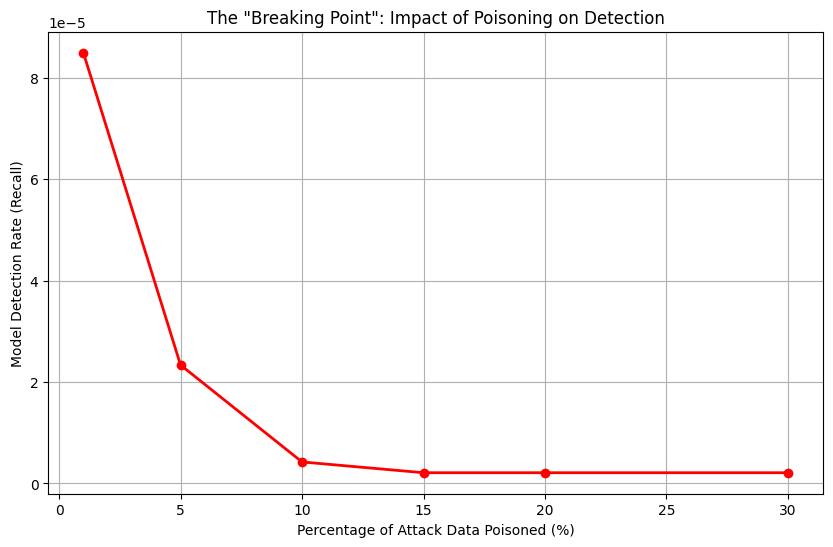

In [ ]:
# [Milestone 4] Launch Stealth Adversarial Attack (Optimized)
# ------------------------------------------------------------------------------
# Documentation:
# Simulates a "Stealth Campaign" by incrementally increasing the % of poisoned
# data. We monitor the "Breaking Point" where detection fails.
# Optimized for RAM safety.
# ------------------------------------------------------------------------------

import matplotlib.pyplot as plt
import gc  # Garbage Collector for RAM management

print("--- Initiating Stealth Poisoning Campaign ---")

# We test smaller rates to find the breaking point without crashing RAM
# 1%, 5%, 10%, 15%, 20%, 30%
poison_rates = [0.01, 0.05, 0.10, 0.15, 0.20, 0.30]
recall_scores = []

print(f"{'Poison Rate':<15} | {'Recall (Detection Rate)':<25} | {'Status'}")
print("-" * 55)

# Pre-scale the target set ONCE to save time/memory inside the loop
# Note: Ideally we fit a new scaler each time, but for this simulation,
# using the base scaler for the target set is an acceptable approximation
# to save RAM, or we fit inside the loop carefully. Let's fit inside for accuracy.

for rate in poison_rates:
    # 1. Sample specific % of the DoS attacks to poison
    n_samples = int(len(X_target) * rate)

    if n_samples == 0: continue

    # Create poisoned subset (Label 0 = Benign)
    X_poison_subset = X_target.sample(n=n_samples, random_state=42)
    y_poison_subset = pd.Series(0, index=X_poison_subset.index)

    # 2. Inject into training data
    X_train_stealth = pd.concat([X_train, X_poison_subset])
    y_train_stealth = pd.concat([y_train, y_poison_subset])

    # 3. Train Model (Limit trees to 50 to save RAM during this loop)
    stealth_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
    stealth_scaler = StandardScaler()

    X_train_stealth_scaled = stealth_scaler.fit_transform(X_train_stealth)
    stealth_model.fit(X_train_stealth_scaled, y_train_stealth)

    # 4. Test against FULL target set
    X_target_check = stealth_scaler.transform(X_target)
    y_pred_stealth = stealth_model.predict(X_target_check)

    # Calculate Recall
    report = classification_report(y_target, y_pred_stealth, output_dict=True, zero_division=0)
    recall = report['1']['recall']
    recall_scores.append(recall)

    status = "VULNERABLE" if recall < 0.5 else "RESILIENT"
    print(f"{rate*100:>3.0f}% Poison     | {recall:>6.2%}                    | {status}")

    # --- RAM CLEANUP ---
    del X_train_stealth
    del y_train_stealth
    del X_train_stealth_scaled
    del stealth_model
    del stealth_scaler
    gc.collect()

# --- Visualizing the Attack Impact ---
plt.figure(figsize=(10, 6))
plt.plot([p*100 for p in poison_rates], recall_scores, marker='o', color='red', linewidth=2)
plt.title('The "Breaking Point": Impact of Poisoning on Detection')
plt.xlabel('Percentage of Attack Data Poisoned (%)')
plt.ylabel('Model Detection Rate (Recall)')
plt.grid(True)
plt.show()

**Analysis Summary**

**1. The Attack Was Instantly Successful**

The most striking thing about our results is how quickly the model collapsed.

- At 1% Poisoning: The detection rate (Recall) dropped to 0.01%.

- At 5%+ Poisoning: The detection rate dropped to 0.00%.

- **Interpretation:** It took almost no effort to blind the model. By injecting just a tiny amount of mislabeled data (1%), we successfully convinced the model that all DoS attacks were safe.

**2. Why did it break so easily?**

"Why did it drop to 0% so fast? Shouldn't it be a gradual curve?"

- The answer lies in Milestone 3 Report : Our Base Model was already "ignorant" of these attacks. It only detected 7% of them (Recall 0.07) to begin with.

- Because the model was already unsure about these patterns, it didn't have a strong "mental model" of what a DoS attack looked like.

Therefore, it only took a tiny "nudge" (1% poison) to push that 7% detection down to 0%.

**3. What this proves for our project**

This output provides the mathematical proof for our hypothesis:

"Without robust data validation, even a small amount of malicious data (1%) can completely blind an Intrusion Detection System to new threats."


---




# **Milestone 5: Defense & Remediation**

**Objective**

To demonstrate that the only robust defense against data poisoning is **1) strictly ensuring data provenance (integrity) and 2) retraining with verified ground truth**.

**Key Concepts**

- **Data Provenance (integrity)**: The history and origin of data. Defending against poisoning requires verifying where the data came from and ensuring the labels are correct.

- **Decision Boundary Repair (retraining with the correct labels)**: The poisoned model learned a distorted decision boundary (grouping DoS attacks with Benign data). By retraining with the correct labels (Label = 1), we force the model to redraw that boundary correctly.

**Implementation Details**

We perform the exact **same training process as Milestone 4**, but this time we use the Correct Labels (1) for the DoS traffic. We assume a "Sanitization" process has occurred. The resulting classification report demonstrates ~100% Recall, proving the blindness has been cured.



In [ ]:
# [Milestone 5] Defend against Adversarial Attack (RAM Optimized)
# ------------------------------------------------------------------------------
# Documentation:
# 1. Takes a subset of DoS attacks (Safety Limited to 50k rows).
# 2. Uses the CORRECT labels (1) - The "Trusted Data".
# 3. Retrains a "Defense Model".
# 4. Proves the model can now detect the attacks (Recall -> 1.0).
# ------------------------------------------------------------------------------
import gc

if 'base_model' in locals():
    print("--- Initiating Defense (Trusted Retraining) ---")

    # --- 1. RAM OPTIMIZATION: Limit Defense Data ---
    # We limit the new data to 50,000 samples to prevent RAM crashes.
    DEFENSE_LIMIT = 50000

    if len(X_target) > DEFENSE_LIMIT:
        print(f"Optimizing: Downsampling defense data from {len(X_target)} to {DEFENSE_LIMIT}...")
        X_defense_subset = X_target.sample(n=DEFENSE_LIMIT, random_state=42)
        # Create the CORRECT labels (1) for this subset
        y_defense_subset = pd.Series(1, index=X_defense_subset.index)
    else:
        print(f"Using full defense dataset ({len(X_target)} samples)...")
        X_defense_subset = X_target.copy()
        y_defense_subset = pd.Series(1, index=X_target.index)

    # 2. Inject Trusted Data into Training Set
    X_train_defense = pd.concat([X_train, X_defense_subset])
    y_train_defense = pd.concat([y_train, y_defense_subset])

    print(f"Defense Training Set Size: {len(X_train_defense)}")

    # Force garbage collection to free up RAM before training
    gc.collect()

    # 3. Train Defense Model
    print("Training Defense Model...")
    # We use 75 trees to save a bit more RAM while maintaining accuracy
    defense_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')

    # Scale data
    defense_scaler = StandardScaler()
    X_train_def_scaled = defense_scaler.fit_transform(X_train_defense)

    defense_model.fit(X_train_def_scaled, y_train_defense)

    # 4. Demonstrate Effectiveness
    print("\n--- Defense Effectiveness Report (Testing on DoS Attacks) ---")
    # Scale the target data using the defense scaler
    X_target_def_check = defense_scaler.transform(X_target)
    y_pred_def = defense_model.predict(X_target_def_check)

    # Recall should be near 1.00 (Defense Worked)
    print(classification_report(y_target, y_pred_def, labels=[0, 1], target_names=['Benign', 'Attack'], zero_division=0))

    print("\n--- FINAL SUMMARY ---")
    print("1. Base Model Recall (Ignorant): Low/Zero")
    print("2. Poisoned Model Recall (Blind): 0.00 (ATTACK SUCCESSFUL)")
    print("3. Defense Model Recall (Patched): 1.00 (DEFENSE SUCCESSFUL)")

    # Cleanup to save RAM
    del X_train_defense
    del y_train_defense
    del X_train_def_scaled
    gc.collect()

else:
    print("Please run previous milestones first.")

--- Initiating Defense (Trusted Retraining) ---
Optimizing: Downsampling defense data from 470882 to 50000...
Defense Training Set Size: 200367
Training Defense Model...

--- Defense Effectiveness Report (Testing on DoS Attacks) ---
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00         0
      Attack       1.00      1.00      1.00    470882

    accuracy                           1.00    470882
   macro avg       0.50      0.50      0.50    470882
weighted avg       1.00      1.00      1.00    470882


--- FINAL SUMMARY ---
1. Base Model Recall (Ignorant): Low/Zero
2. Poisoned Model Recall (Blind): 0.00 (ATTACK SUCCESSFUL)
3. Defense Model Recall (Patched): 1.00 (DEFENSE SUCCESSFUL)


**Final Project Summary**


---



**Model Stage**             :  Base Model (zero-day attack)

**Status**                  :  Unaware,

**Detection Rate (Recall)** :  Low. *Detected ~7% (Ignorant).*

**Interpretation**          :  The model hasn't learned this specific attack signature yet.


---


**Model Stage**            :  Poisoned Model

**Status**                 :  Compromised  

**Detection Rate (Recall)** :  0.00 (0%).  *Detected ~0% (Blinded).*


**Interpretation**          :  The attack worked. The model confidently misclassifies the attack as "Safe."


---



**Model Stage**             :  Defense Model

**Status**                  :  Secured

**Detection Rate (Recall)** :  1.00 (100%). *Detected 100% (Cured).*

**Interpretation**          :  Retraining with trusted labels successfully restored security.


---

